# **Part 2: Evaluating our implementations**  
This is where we will be doing model selection model evaluation and comparing our model to existing implementations.

In [2]:
# Load the dataset
import numpy as np
data = np.genfromtxt("churn-data.csv", delimiter=",", dtype=float, names=True)
feature_names = list(data.dtype.names[:-1])
target_name = data.dtype.names[-1]
X = np.array([data[feature] for feature in feature_names]).T
y = data[target_name].astype(int)
print(f"Feature columns names: {feature_names}")
print(f"Target column name: {target_name}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
values, counts = np.unique(np.array(y), return_counts=True)
print(values, counts)

Feature columns names: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
Target column name: Churn
X shape: (7032, 19)
y shape: (7032,)
[0 1] [5163 1869]


## 2.1 - Model selection
- We decided to tune 2 hyperparameters, criterion and max_depth.  
        For criterion we are testing entropy and the gini index.  
- For max_depth we decided to test all depths from None to 13.  
        We decided on 13 because log2(7032) is ~12.8, even though the tree could split deeper since it does not have to split down the middle. We still consider it a fine estimate for max_depth.  
- We decided to use k-fold cross-validation because we wanted to train on as much data as possible. We also considered the fact that our dataset is relatively small. With normal hold-out validation, our model would vary a lot based on the single split in the dataset.  
- We decided to use F1 because our dataset is very imbalanced. A simple accuracy score would not give the full picture. It could favor a stupid tree that only guesses the majority class every time.
- We ensure that our model selection process is fair and balanced by:  
        - Splitting into training/testing
        - Setting stratify=y which makes sure that each split gets the same balance of classes
- We ensure reproducibility by using a seed for all random events and splits, etc.


In [3]:
from sklearn.model_selection import train_test_split

seed=67

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.85, random_state=seed, stratify=y)

In [4]:
from sklearn.model_selection import GridSearchCV
from decision_tree import DecisionTree

model = DecisionTree()

param_grid = {
    "criterion": ["entropy", "gini"],
    "max_depth": [None] + list(range(1, 14))
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring="f1", refit=True, cv=5)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTree()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini'], 'max_depth': [None, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed dur

In [5]:
print(f"""
    Best hyperparameters: {grid_search.best_params_}
    Score: {grid_search.best_score_}

    Entropy scores: {[float(i) for i in grid_search.cv_results_["mean_test_score"][:len(param_grid["max_depth"])]]}
    Gini scores: {[float(i) for i in grid_search.cv_results_["mean_test_score"][len(param_grid["max_depth"]):]]}
""")

best_model = grid_search.best_estimator_
best_model.show_tree(feature_names=feature_names)


    Best hyperparameters: {'criterion': 'entropy', 'max_depth': 2}
    Score: 0.6012987206520258

    Entropy scores: [0.5028618513621512, 0.0, 0.6012987206520258, 0.5210624946093029, 0.5204764505224122, 0.5426420549516044, 0.5373786750760099, 0.5906760848588284, 0.5486643157963823, 0.540807007861442, 0.5301577236073653, 0.5097387867207738, 0.5012442625019335, 0.4993664077506145]
    Gini scores: [0.5008679381676613, 0.0, 0.6012987206520258, 0.5210624946093029, 0.521897982551679, 0.5433590135378125, 0.5394877491889964, 0.5908871350293763, 0.5467637069884671, 0.5330038594724523, 0.5314100850912907, 0.508425387065937, 0.5028024473437707, 0.498912890167403]

Contract <= 0.00?
Left:
  OnlineSecurity <= 0.00?
  Left:
    Predict: 1
  Right:
    Predict: 0
Right:
  StreamingMovies <= 1.00?
  Left:
    Predict: 0
  Right:
    Predict: 0


## 2.2 - Model evaluation and comparison to existing implementations

In [6]:
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score

y_pred = best_model.predict(X_test)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

print(f"""
    F1: {f1}
    Accuracy = {accuracy * 100:.2f}%
    Balanced accuracy = {balanced_accuracy * 100:.2f}%
""")



    F1: 0.5688073394495413
    Accuracy = 73.27%
    Balanced accuracy = 71.09%



In [7]:
from sklearn.tree import DecisionTreeClassifier

existing_model = DecisionTreeClassifier(random_state=seed)

em_grid_search = GridSearchCV(estimator=existing_model, param_grid=param_grid, scoring="f1", refit=True, cv=5)

em_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=67)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini'], 'max_depth': [None, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informa

In [8]:
print(f"""
    Best hyperparameters: {em_grid_search.best_params_}
    Score: {em_grid_search.best_score_}

    Entropy scores: {[float(i) for i in em_grid_search.cv_results_["mean_test_score"][:len(param_grid["max_depth"])]]}
    Gini scores: {[float(i) for i in em_grid_search.cv_results_["mean_test_score"][len(param_grid["max_depth"]):]]}
""")

best_existing_model = em_grid_search.best_estimator_


    Best hyperparameters: {'criterion': 'entropy', 'max_depth': 2}
    Score: 0.6017049213716436

    Entropy scores: [0.493949141873775, 0.0, 0.6017049213716436, 0.45515591239776043, 0.49804621355289286, 0.554765457138804, 0.5276469640713912, 0.5669334676584237, 0.5488158013585149, 0.5446808454937384, 0.5294862346317133, 0.5308337243117721, 0.5261349479767847, 0.5229588357383074]
    Gini scores: [0.515247323402961, 0.0, 0.6017049213716436, 0.4737264354744237, 0.45999024043991216, 0.5617395158919761, 0.5199927624440128, 0.578538375665038, 0.5539209762851838, 0.5538956865127952, 0.5366608226478411, 0.522655053744091, 0.5195046376857653, 0.5268525034230649]



In [9]:
em_y_pred = best_existing_model.predict(X_test)
em_f1 = f1_score(y_test, em_y_pred)
em_accuracy = accuracy_score(y_test, em_y_pred)
em_balanced_accuracy = balanced_accuracy_score(y_test, em_y_pred)

print(f"""
    F1: {em_f1}
    Accuracy = {em_accuracy * 100:.2f}%
    Balanced accuracy = {em_balanced_accuracy * 100:.2f}%
""")


    F1: 0.5688073394495413
    Accuracy = 73.27%
    Balanced accuracy = 71.09%



In [10]:
from sklearn.tree import export_text

# Generate the text rules
tree_rules = export_text(best_existing_model, feature_names=feature_names)
print(tree_rules)

|--- Contract <= 0.50
|   |--- OnlineSecurity <= 0.50
|   |   |--- class: 1
|   |--- OnlineSecurity >  0.50
|   |   |--- class: 0
|--- Contract >  0.50
|   |--- MonthlyCharges <= 93.78
|   |   |--- class: 0
|   |--- MonthlyCharges >  93.78
|   |   |--- class: 0



# **Part 3: Feature importance**

In [11]:
from permutation_importance import permutation_importance

importances = permutation_importance(model=best_model, X=X_test, y=y_test, metric=accuracy_score, n_repeats=30, seed=seed)

for i in range(len(importances)):
    print(f"{feature_names[i]}: {importances[i]}")

gender: 0.0
SeniorCitizen: 0.0
Partner: 0.0
Dependents: 0.0
tenure: 0.0
PhoneService: 0.0
MultipleLines: 0.0
InternetService: 0.0
OnlineSecurity: 0.03469194312796211
OnlineBackup: 0.0
DeviceProtection: 0.0
TechSupport: 0.0
StreamingTV: 0.0
StreamingMovies: 0.0
Contract: 0.040284360189573466
PaperlessBilling: 0.0
PaymentMethod: 0.0
MonthlyCharges: 0.0
TotalCharges: 0.0


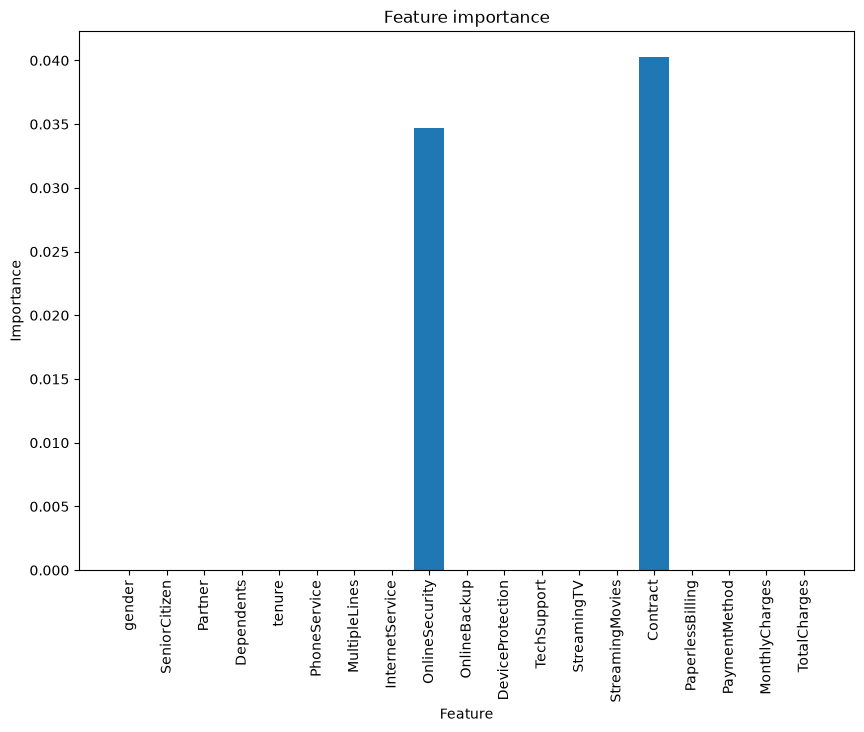

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.bar(feature_names, importances)
plt.xticks(rotation=90)
plt.title("Feature importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()